## Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

## Google Drive (Dataset)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = '/content/drive/MyDrive/DatasetFinal'

## Data Generators (Augementation)

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

## Load Dataset

In [5]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 240 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [6]:
print(train_data.class_indices)

{'Angry': 0, 'Happy': 1, 'Surprised': 2}


## CNN Model

In [7]:
model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(layers.MaxPooling2D(2,2))

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Dense
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

# Output
model.add(layers.Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Early Stopping

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## Train Model

In [9]:
history = model.fit(
    train_data,
    epochs=30,
    validation_data=validation_data,
    callbacks=[early_stop]
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 58s 7s/step - accuracy: 0.3542 - loss: 1.1093 - val_accuracy: 0.3333 - val_loss: 1.0977
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 989ms/step - accuracy: 0.3167 - loss: 1.1037 - val_accuracy: 0.4333 - val_loss: 1.0988
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2542 - loss: 1.1031 - val_accuracy: 0.3333 - val_loss: 1.0981
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 971ms/step - accuracy: 0.3375 - loss: 1.0987 - val_accuracy: 0.4500 - val_loss: 1.0976
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3917 - loss: 1.0975 - val_accuracy: 0.4000 - val_loss: 1.0965
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 910ms/step - accuracy: 0.3708 - loss: 1.0963 - val_accuracy: 0.5333 - val_loss: 1.0922
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4125 - loss: 1.0898 - val_accuracy: 0.4500 - val_loss: 1.0784
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 978ms/step - accuracy: 0.4792 - loss: 1.0714 - val_accuracy: 0.5333 - val_loss: 1.0118
Epo

## Visualization

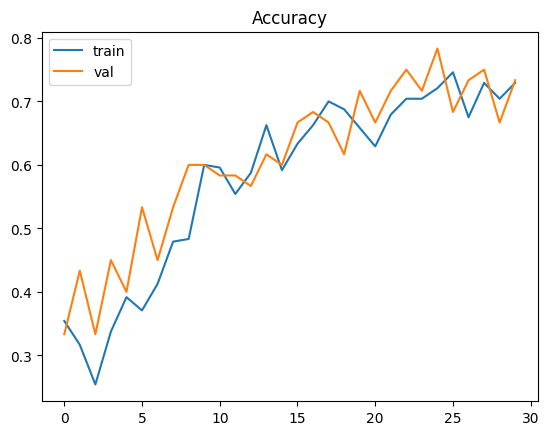

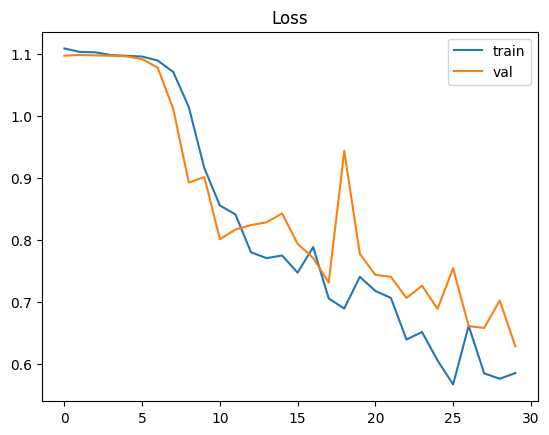

In [10]:
# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [23]:
print(f"Last training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Last validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Last training loss: {history.history['loss'][-1]:.4f}")
print(f"Last validation loss: {history.history['val_loss'][-1]:.4f}")

Last training accuracy: 0.7292
Last validation accuracy: 0.7333
Last training loss: 0.5853
Last validation loss: 0.6284


## Evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 886ms/step


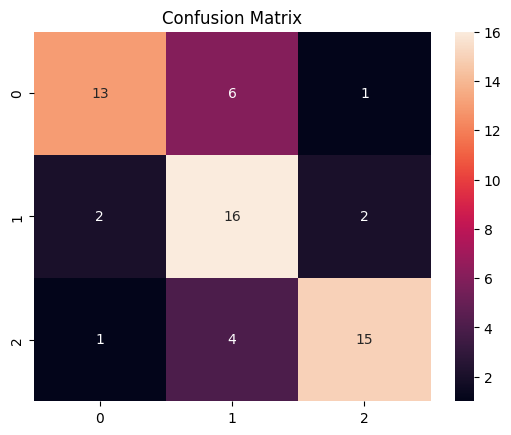

              precision    recall  f1-score   support

       Angry       0.81      0.65      0.72        20
       Happy       0.62      0.80      0.70        20
   Surprised       0.83      0.75      0.79        20

    accuracy                           0.73        60
   macro avg       0.75      0.73      0.74        60
weighted avg       0.75      0.73      0.74        60



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

validation_data.reset()

Y_pred = model.predict(validation_data)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_data.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# FIX LABEL ORDER
class_indices = train_data.class_indices
class_labels = {v: k for k, v in class_indices.items()}

target_names = [class_labels[i] for i in range(len(class_labels))]

print(classification_report(y_true, y_pred, target_names=target_names))

## Save Model

In [12]:
model.save('/content/drive/MyDrive/emotion_model.h5')

## Prediction

In [14]:
class_labels = ['Angry', 'Happy', 'Surprised']

Saving WIN_20260430_01_13_12_Pro.jpg to WIN_20260430_01_13_12_Pro.jpg
Shape: (1, 48, 48, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Raw prediction: [[0.91208786 0.06985765 0.01805446]]


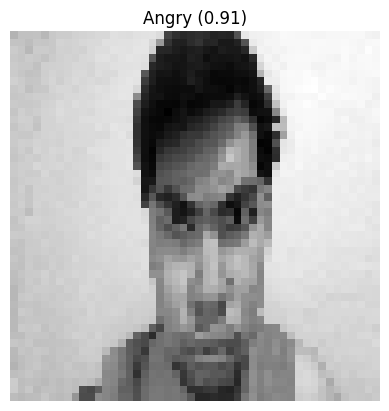

Prediction: Angry
Confidence: 0.91208786


In [22]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load image EXACTLY like training
img = image.load_img(filename, target_size=(48,48), color_mode='grayscale')

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

print("Shape:", img_array.shape)  # should be (1,48,48,1)

prediction = model.predict(img_array)

print("Raw prediction:", prediction)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

predicted_label = class_labels[predicted_class]

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title(f"{predicted_label} ({confidence:.2f})")
plt.show()

print("Prediction:", predicted_label)
print("Confidence:", confidence)